In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [4]:
# How does the choice of Ship Mode impact the overall Shipping Cost and net profitability?

In [27]:
df[['Sales','Shipping Cost','Profit']]

,Sales,Shipping Cost,Profit
0,19.7760,0.79,-13.84
1,11.5440,0.97,-5.22
2,29.8500,3.71,-4.80
3,1.3230,0.06,-3.09
4,131.4876,0.00,25.17
...,...,...,...
51365,108.5400,11.76,34.56
51366,783.9600,64.42,219.51
51367,39.8400,5.84,-12.96
51368,38.4345,2.96,3.66


In [5]:
shipcost_profit_by_shipmode = df.groupby(df['Ship Mode'])[['Shipping Cost','Profit']].agg(
    total_shipping_cost = ('Shipping Cost','sum'),
    total_profit = ('Profit','sum')
).round(2)

shipcost_profit_by_shipmode

,total_shipping_cost,total_profit
Ship Mode,,
First Class,296765.74,206419.52
Same Day,111786.37,76232.07
Second Class,303651.80,287081.28
Standard Class,589185.85,873895.22
Unknown,24456.92,26967.46


In [6]:
shipcost_profit_by_shipmode.reset_index(inplace=True)
shipcost_profit_by_shipmode

,Ship Mode,total_shipping_cost,total_profit
0,First Class,296765.74,206419.52
1,Same Day,111786.37,76232.07
2,Second Class,303651.80,287081.28
3,Standard Class,589185.85,873895.22
4,Unknown,24456.92,26967.46


In [8]:
shipcost_profit_by_shipmode['Ship Mode'] = shipcost_profit_by_shipmode['Ship Mode'].replace('Unknown','Other')

In [9]:
shipcost_profit_by_shipmode['Ship Mode']

0       First Class
1          Same Day
2      Second Class
3    Standard Class
4             Other
Name: Ship Mode, dtype: str

In [13]:
shipcost_profit_by_shipmode.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ship Mode            5 non-null      str    
 1   total_shipping_cost  5 non-null      float64
 2   total_profit         5 non-null      float64
dtypes: float64(2), str(1)
memory usage: 252.0 bytes


In [21]:
shipcost_profit_by_shipmode

,Ship Mode,total_shipping_cost,total_profit
0,First Class,296765.74,206419.52
1,Same Day,111786.37,76232.07
2,Second Class,303651.80,287081.28
3,Standard Class,589185.85,873895.22
4,Other,24456.92,26967.46


[]

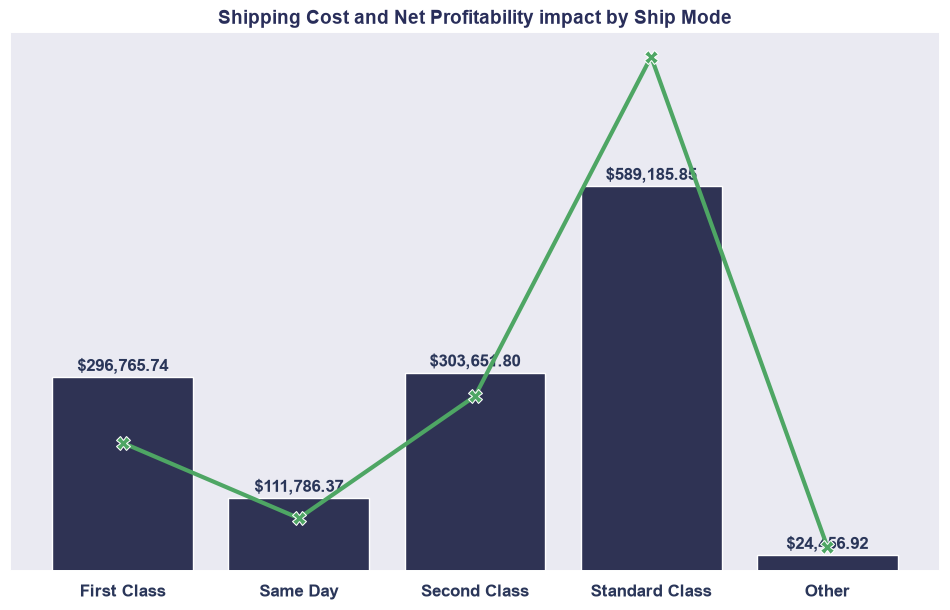

In [112]:
sns.set_theme()

fig, ax = plt.subplots(figsize=(12,7))

sns.barplot(
    data=shipcost_profit_by_shipmode,
    x='Ship Mode',
    y='total_shipping_cost',
    ax=ax,
    color='#292E5A'
)
ax.grid(False)
ax.margins(x=0.2, y=0.4)
ax.set_title('Shipping Cost and Net Profitability impact by Ship Mode', color='#292E5A', fontsize=14, fontweight='bold')

# =============== x-axis ===============
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=12, labelcolor='#2A3659')
plt.rcParams['font.weight'] = 'bold'


# =============== y-axis ===============
ax.set_ylabel('')
ax.set_yticks([])
ax.set_yticklabels([])

# applies fontweight to xticklabels
for label in ax.get_xticklabels():
    label.set_weight('bold')

# shows bar values
for container in ax.containers:
    ax.bar_label(container, fmt='${:,.2f}', fontsize=12, padding=2, weight='bold', color='#2A3659')

ax1 = ax.twinx()

sns.lineplot(
    data=shipcost_profit_by_shipmode,
    x='Ship Mode',
    y='total_profit',
    ax=ax1,
    color='#4EA664',
    marker='X',
    markersize=10,
    linewidth=3
)

# =============== ax1 y-axis ===============
ax1.set_ylabel('')
ax1.set_yticks([])
ax1.set_yticklabels([])

In [113]:
# Business Question 11:
# How does the choice of Ship Mode impact the overall Shipping Cost and net profitability?

# Answer:
# Standard Class has the highest Shipping Cost and Net Profitability in Ship Mode with Shipping Expense of around $590k and total Profit of around
# $870k whilst Second Class comes in 2nd with Shipping Fee of around $303k and total profit of near $287k, almost 50% difference in both measures.